# Welcome!

In [1]:
# Core scientific stack
import numpy as np
import matplotlib.pyplot as plt

# Visualization helpers
from skimage.exposure import equalize_hist, rescale_intensity

def percentile_eq(image, p_low=2, p_high=98):
    """
    Contrast stretching based on percentiles p_low and p_high.

    Parameters
    ----------
    image : np.ndarray
        Input 2D image (any numeric dtype).
    p_low : float
        Lower percentile (default = 2).
    p_high : float
        Upper percentile (default = 98).

    Returns
    -------
    np.ndarray
        Image rescaled after percentile stretching.
    """
    img = image.astype(np.float32)

    # Compute percentiles
    p2, p98 = np.percentile(img, (p_low, p_high))

    # Stretch
    img_stretched = rescale_intensity(img, in_range=(p2, p98))

    return img_stretched

In [21]:
from shimexpy import load_image

# Load test images
reference_img = load_image("../tests/example_data/flat_roi2.tif")
sample_img = load_image("../tests/example_data/smp_roi2.tif")
bright_img = load_image("../tests/example_data/bright_roi2.tif")
dark_img = load_image("../tests/example_data/dark_roi2.tif")

In [22]:
# SHIMEXPY: main processing functions
from shimexpy import ffc, FFCQualityAssessment

reference_ffc = ffc(reference_img, dark_img, bright_img)
sample_ffc = ffc(sample_img, dark_img, bright_img)

In [23]:
from shimexpy import shi_fft

fft_ref = shi_fft(reference_ffc, logspect=True)
fft_smp = shi_fft(sample_ffc, logspect=True)

In [24]:
# ============================================================
# FFT + Harmonic Extraction + Visualization (2×4 grid)
# ============================================================
from shimexpy import spatial_harmonics_of_fourier_spectrum

# --- Compute FFT of the reference image ---
fft_ref = shi_fft(reference_ffc, projected_grid=5)  # Note that parameter logspect was not specified

# --- Extract the spatial harmonics automatically ---
ref_harmonics, ref_block_grid = spatial_harmonics_of_fourier_spectrum(
    fft_ref.fft,
    fft_ref.ky,
    fft_ref.kx,
    reference=True
)

smp_harmonics, smp_block_grid = spatial_harmonics_of_fourier_spectrum(
    fft_ref.fft,
    fft_ref.ky,
    fft_ref.kx,
    reference=True
)

In [25]:
from shimexpy import get_harmonics

ref_abs, ref_scat, ref_dpc, ref_block_grid = get_harmonics(
    reference_ffc,
    projected_grid=5,
    unwrap=None   # default → skimage.unwrap_phase
)

smp_abs, smp_scat, smp_dpc, smp_block_grid = get_harmonics(
    sample_ffc,
    projected_grid=5,
    unwrap=None   # default → skimage.unwrap_phase
)

In [26]:
from shimexpy import get_contrast

smp_scat_v = get_contrast(
    sample_ffc,
    ref_scat,
    ref_block_grid,
    type_of_contrast="vertical_scattering",
    unwrap=None   # default → skimage.unwrap_phase
)

smp_scat_h = get_contrast(
    sample_ffc,
    ref_scat,
    ref_block_grid,
    type_of_contrast="horizontal_scattering",
    unwrap=None   # default → skimage.unwrap_phase
)

smp_scat_b = get_contrast(
    sample_ffc,
    ref_scat,
    ref_block_grid,
    type_of_contrast="bidirectional_scattering",
    unwrap=None   # default → skimage.unwrap_phase
)

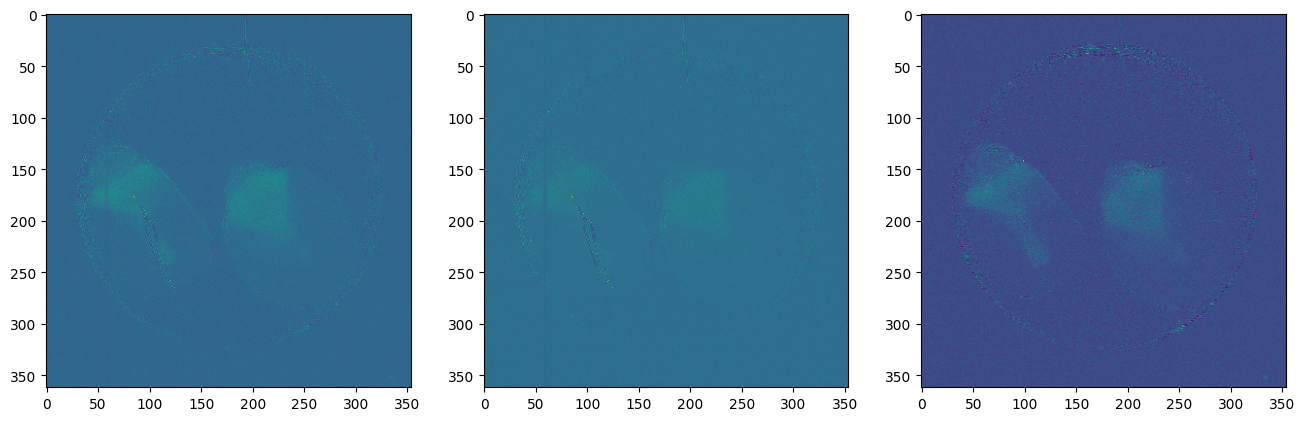

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

ax[0].imshow(smp_scat_b)
ax[1].imshow(smp_scat_h)
ax[2].imshow(smp_scat_v)

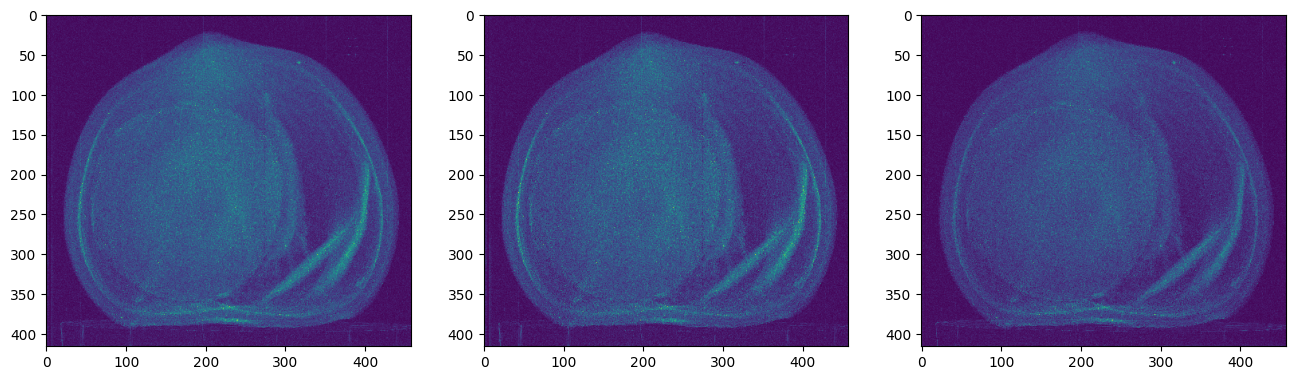

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

ax[0].imshow(smp_scat_b)
ax[1].imshow(smp_scat_h)
ax[2].imshow(smp_scat_v)

# ax.imshow(smp_scat_b)

--------------------------------------------
**3) get_contrasts (main 3 contrasts)**

--------------------------------------------

In [18]:
from shimexpy import get_contrasts

abs_contrast, scat_contrast, dpc_contrast = get_contrasts(
    sample_ffc,
    (ref_abs, ref_scat, ref_dpc),
    ref_block_grid,
    unwrap=None
)

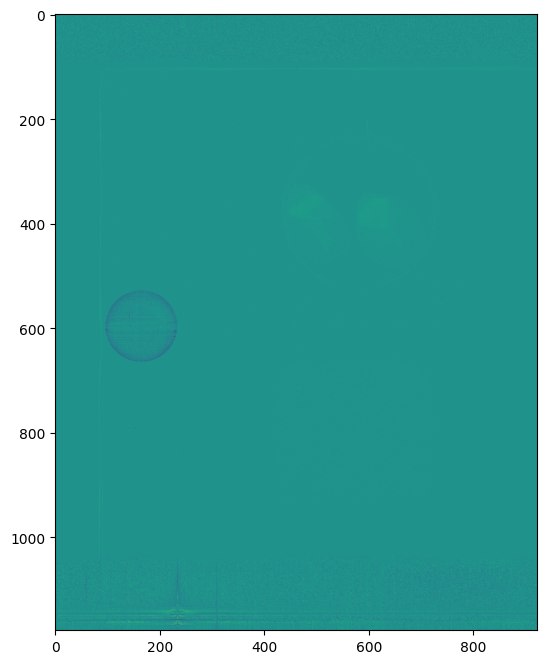

In [33]:
fig, axes = plt.subplots(1, 1, figsize=(8, 8))

axes.imshow(scat_contrast)
# axes[0].imshow(percentile_eq(abs_contrast), cmap="gray")
# axes[0].set_title("Absorption Contrast")
# axes[0].axis("off")

# axes[1].imshow(percentile_eq(scat_contrast), cmap="gray")
# axes[1].set_title("2D scattering contrast")
# axes[1].axis("off")

# axes[2].imshow(percentile_eq(dpc_contrast), cmap="gray")
# axes[2].set_title("2D differential phase contrast")
# axes[2].axis("off")

# fig.tight_layout()

--------------------------------------------
**4) get_all_contrasts**

--------------------------------------------

In [15]:
from shimexpy import get_all_contrasts

abs_c, scat_c, dpc_c = get_all_contrasts(
    sample_ffc,
    reference_ffc,
    projected_grid=5,
    unwrap=None
)

In [16]:
import numpy as np

def integrated_darkfield(scat_c, exclude_dc=True, log_ratio=False):
    """
    Compute an orientation-independent (isotropic) dark-field metric
    by integrating all interferential spatial harmonics.

    Parameters
    ----------
    scat_c : dict or xarray.DataArray
        Scattering contrast containing spatial harmonics.
        Expected harmonics: (0,±1), (±1,0), (±1,±1)
    exclude_dc : bool, default True
        Exclude (0,0) harmonic if present.
    log_ratio : bool, default False
        If True, assume scat_c already contains ratios and apply -log().
        If False, assume scat_c is already a contrast-like quantity.

    Returns
    -------
    darkfield_iso : np.ndarray
        Orientation-independent dark-field image.
    """

    # -------- case 1: dict[(m,n)] -> ndarray --------
    if isinstance(scat_c, dict):
        fields = []
        for (m, n), img in scat_c.items():
            if exclude_dc and (m == 0 and n == 0):
                continue

            val = np.abs(np.asarray(img))
            if log_ratio:
                val = -np.log(val)

            fields.append(val)

        if not fields:
            raise ValueError("No valid harmonics found for dark-field integration.")

        return np.mean(fields, axis=0)

    # -------- case 2: xarray.DataArray --------
    try:
        import xarray as xr
        if isinstance(scat_c, xr.DataArray):

            da = scat_c

            # remove DC if present
            if exclude_dc and {"m", "n"} <= set(da.dims):
                da = da.where(~((da.m == 0) & (da.n == 0)), drop=True)

            da = np.abs(da)

            if log_ratio:
                da = -np.log(da)

            return da.mean(dim=[d for d in da.dims if d not in ("y", "x")]).values
    except ImportError:
        pass

    raise TypeError("Unsupported scat_c type. Expected dict or xarray.DataArray.")


In [17]:
darkfield_iso = integrated_darkfield(
    scat_c,
    exclude_dc=True,
    log_ratio=False
)

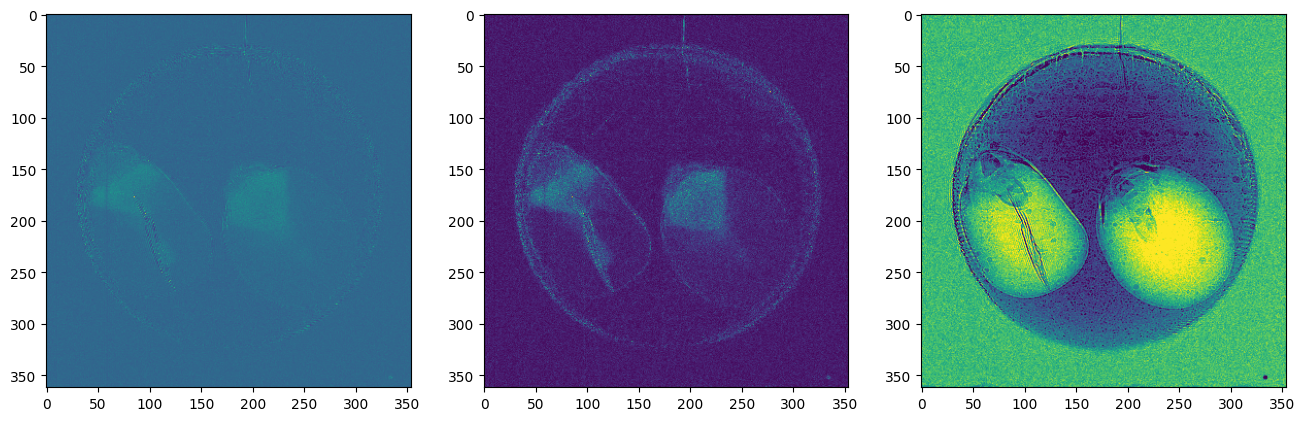

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

ax[0].imshow(scat_contrast)
ax[1].imshow(darkfield_iso)
ax[2].imshow(percentile_eq(abs_c))